STARR FROM THE BEGINING...I DONT KNOW WHAT WILL HAPPEN 

objective---

1-Complete structure, ready to be directly copied and run in a Jupyter Notebook

2-Includes both ViT and ResNet（One Notebook；Two Models；The Same Dataset；The Same Training Loop--Control variables:
Same Dataset
Same Split 
Same Loss 
Same Optimizer 
Same Epoch ）

3-Fully aligned with the regression objective outlined in your PDF

4-Freezes the backbone, training only the regression head

In [157]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

In [158]:
data_dir = "dataset"

level_mapping = {
    "LEV0-Prototype": 1.0,
    "LEV1-Conservative_change": 0.9,
    "LEV2-Partially_change": 0.75,
    "LEV3-Completely_change_into_specific_items": 0.5,
    "LEV4-Almost_abstract_shape_with_a_bit_inherent_feature": 0.25,
    "LEV5-Completely_abstract": 0.1,
    "LEV6-NonCat": 0.0
}

image_paths = []
labels = []

for folder_name in level_mapping:
    folder_path = os.path.join(data_dir, folder_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(folder_path, file_name))
            labels.append(level_mapping[folder_name])

print("Distribution:", Counter(labels))

Distribution: Counter({0.75: 124, 0.25: 105, 0.0: 98, 0.5: 63, 1.0: 51, 0.1: 29, 0.9: 24})


In [159]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [160]:
class CatDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [161]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [162]:
train_dataset = CatDataset(train_paths, train_labels, transform)
val_dataset = CatDataset(val_paths, val_labels, transform)

class_counts = Counter(train_labels)
sample_weights = [1.0 / class_counts[label] for label in train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [163]:
class ResNetRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "resnet50",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return output, features

In [164]:
class ViTRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return output, features

In [165]:
##NEWLY ADDED
class ResNetFrozen(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "resnet50",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        feats = self.backbone(x)
        out = self.regressor(feats)
        return out, feats

In [166]:
##NEWLY ADDED
class ResNetPartial(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "resnet50",
            pretrained=True,
            num_classes=0
        )

        for name, param in self.backbone.named_parameters():
            if "layer4" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        feats = self.backbone(x)
        out = self.regressor(feats)
        return out, feats

In [167]:
##NEWLY ADDED
class ViTFrozen(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        feats = self.backbone(x)
        out = self.regressor(feats)
        return out, feats

In [168]:
##NEWLY ADDED
class ViTFrozen(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        feats = self.backbone(x)
        out = self.regressor(feats)
        return out, feats

In [169]:
##NEWLY ADDED
class ViTPartial(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        for name, param in self.backbone.named_parameters():
            if "blocks.10" in name or "blocks.11" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        feats = self.backbone(x)
        out = self.regressor(feats)
        return out, feats

In [170]:
###training 4
def train_model(model, train_loader, epochs=25, lr=1e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs, _ = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

    return model

In [171]:
res_frozen = train_model(ResNetFrozen(), train_loader, epochs=8, lr=1e-3)
res_partial = train_model(ResNetPartial(), train_loader, epochs=10, lr=1e-5)

vit_frozen = train_model(ViTFrozen(), train_loader, epochs=8, lr=1e-3)
vit_partial = train_model(ViTPartial(), train_loader, epochs=10, lr=1e-5)

Epoch 1, Loss: 0.1788
Epoch 2, Loss: 0.1028
Epoch 3, Loss: 0.0642
Epoch 4, Loss: 0.0671
Epoch 5, Loss: 0.0659
Epoch 6, Loss: 0.0594
Epoch 7, Loss: 0.0503
Epoch 8, Loss: 0.0487
Epoch 1, Loss: 0.4259
Epoch 2, Loss: 0.3807
Epoch 3, Loss: 0.3277
Epoch 4, Loss: 0.2575
Epoch 5, Loss: 0.2723
Epoch 6, Loss: 0.2253
Epoch 7, Loss: 0.2003
Epoch 8, Loss: 0.1895
Epoch 9, Loss: 0.1609
Epoch 10, Loss: 0.1556
Epoch 1, Loss: 0.8585
Epoch 2, Loss: 0.2772
Epoch 3, Loss: 0.1697
Epoch 4, Loss: 0.1006
Epoch 5, Loss: 0.0723
Epoch 6, Loss: 0.0874
Epoch 7, Loss: 0.0766
Epoch 8, Loss: 0.0507
Epoch 1, Loss: 0.4041
Epoch 2, Loss: 0.1286
Epoch 3, Loss: 0.0959
Epoch 4, Loss: 0.0652
Epoch 5, Loss: 0.0448
Epoch 6, Loss: 0.0266
Epoch 7, Loss: 0.0243
Epoch 8, Loss: 0.0135
Epoch 9, Loss: 0.0144
Epoch 10, Loss: 0.0081


In [172]:
def collect_outputs(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    preds = []
    labels = []
    features = []

    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)
            outputs, feats = model(images)

            preds.extend(outputs.cpu().numpy().flatten())
            labels.extend(target.numpy())
            features.extend(feats.cpu().numpy())

    return np.array(preds), np.array(labels), np.array(features)

In [173]:
res_f_preds, res_f_labels, res_f_feats = collect_outputs(res_frozen, val_loader)
res_p_preds, res_p_labels, res_p_feats = collect_outputs(res_partial, val_loader)

vit_f_preds, vit_f_labels, vit_f_feats = collect_outputs(vit_frozen, val_loader)
vit_p_preds, vit_p_labels, vit_p_feats = collect_outputs(vit_partial, val_loader)

levels = sorted(set(res_f_labels))

In [174]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_cosine_distances(features, labels, levels):
    centroid_0 = features[labels == 1.0].mean(axis=0).reshape(1, -1)
    centroid_6 = features[labels == 0.0].mean(axis=0).reshape(1, -1)

    dist_to_0 = []
    dist_to_6 = []

    for l in levels:
        f = features[labels == l]

        cos0 = cosine_similarity(f, centroid_0)
        cos6 = cosine_similarity(f, centroid_6)

        dist_to_0.append((1 - cos0).mean())
        dist_to_6.append((1 - cos6).mean())

    return dist_to_0, dist_to_6

In [175]:
res_f_d0, res_f_d6 = compute_cosine_distances(res_f_feats, res_f_labels, levels)
res_p_d0, res_p_d6 = compute_cosine_distances(res_p_feats, res_p_labels, levels)

vit_f_d0, vit_f_d6 = compute_cosine_distances(vit_f_feats, vit_f_labels, levels)
vit_p_d0, vit_p_d6 = compute_cosine_distances(vit_p_feats, vit_p_labels, levels)

In [176]:
from scipy.stats import spearmanr

def collapse_strength(levels, distances):
    rho, _ = spearmanr(levels, distances)
    return rho

In [177]:
print("ResNet Frozen:", collapse_strength(levels, res_f_d0))
print("ResNet Partial:", collapse_strength(levels, res_p_d0))
print("ViT Frozen:", collapse_strength(levels, vit_f_d0))
print("ViT Partial:", collapse_strength(levels, vit_p_d0))

ResNet Frozen: -0.9642857142857145
ResNet Partial: -0.9642857142857145
ViT Frozen: -0.9642857142857145
ViT Partial: -0.9642857142857145


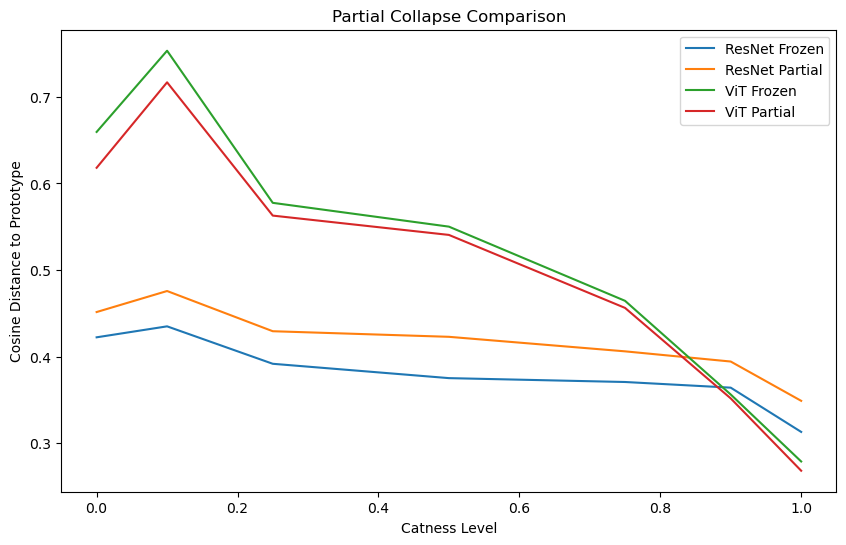

In [178]:
plt.figure(figsize=(10,6))
plt.plot(levels, res_f_d0, label="ResNet Frozen")
plt.plot(levels, res_p_d0, label="ResNet Partial")
plt.plot(levels, vit_f_d0, label="ViT Frozen")
plt.plot(levels, vit_p_d0, label="ViT Partial")

plt.xlabel("Catness Level")
plt.ylabel("Cosine Distance to Prototype")
plt.legend()
plt.title("Partial Collapse Comparison")
plt.show()